In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
print("Shape:", df.shape)

Shape: (891, 12)


In [21]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


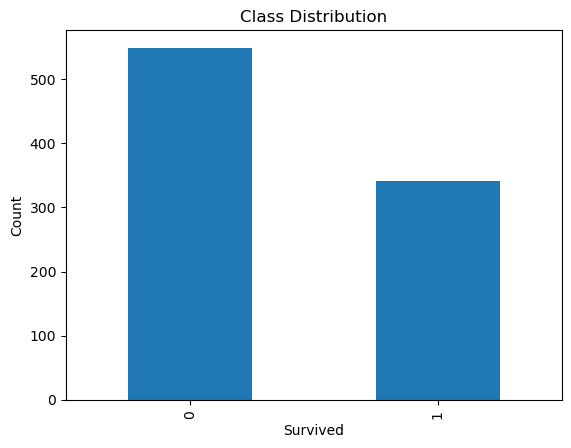

In [26]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

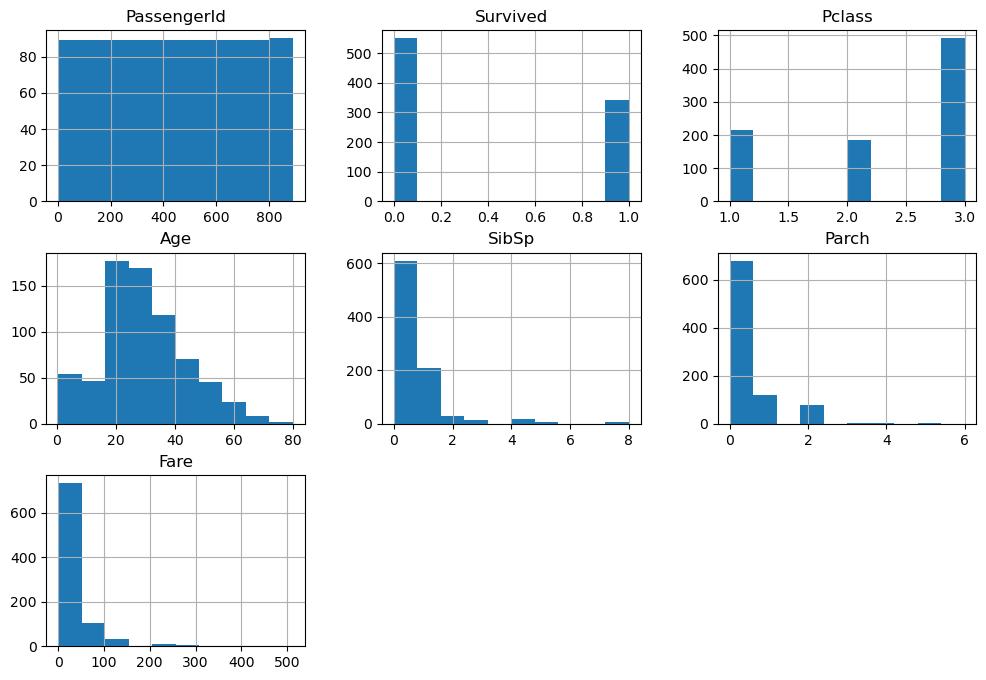

In [27]:
df.hist(figsize=(12, 8))
plt.show()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

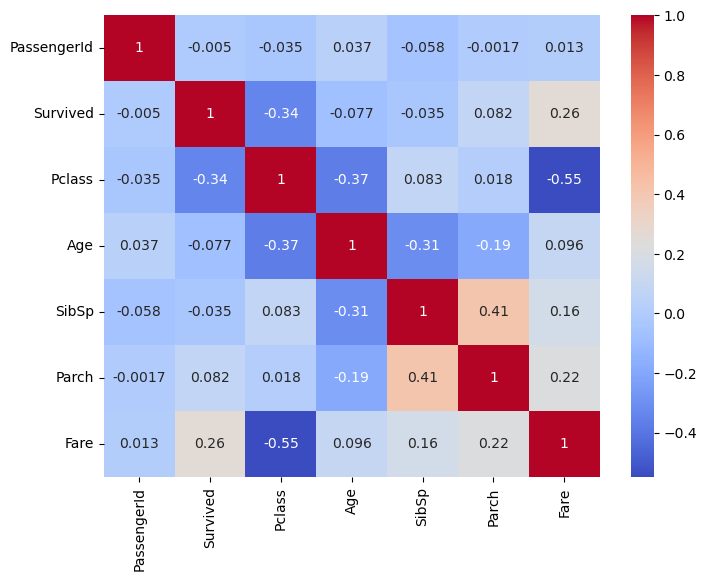

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

In [30]:
df_clean = df.copy()

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])
df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")

df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [31]:
print("Before:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("After :", df_clean.shape)

Before: (891, 12)
After : (891, 12)


In [32]:
print("Before:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("After :", df_clean.shape)

Before: (891, 12)
After : (891, 12)


In [33]:
df_clean[df_clean["Age"] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [34]:
print(df_clean.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [35]:
df_clean["Survived"] = df_clean["Survived"].astype("category")
df_clean["Pclass"] = df_clean["Pclass"].astype("category")

df_clean.dtypes

PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
dtype: object

In [36]:
print("Mean Age :", df_clean["Age"].mean())
print("Median Age:", df_clean["Age"].median())

Mean Age : 29.36158249158249
Median Age: 28.0


In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_clean["Sex_Label"] = label_encoder.fit_transform(df_clean["Sex"])

df_clean[["Sex", "Sex_Label"]].head()

,Sex,Sex_Label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [38]:
df_onehot = pd.get_dummies(
    df_clean,
    columns=["Embarked"],
    dtype=int
)

df_onehot.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_Label,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,1,0,0,1
